In [1]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
from sklearn.linear_model import LinearRegression
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from cartopy.feature import LAKES

C:\Users\x12la\AppData\Local\Temp\ipykernel_31436\2704184582.py:8: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  from geopandas.tools import sjoin


In [2]:
CMAP_CTY_SHP = r"C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp"
LOCUS_IDLING_SHP = r"LOCUS_IL_Idling.shp"

SURROGATE_306_SHP = r"../medhigh_devl_surrogate.shp"   # EPA ONI surrogate (306)
SURROGATE_205_SHP = r"../hotelling_surrogate.shp"      # EPA HOTELLING surrogate (205)

In [3]:
cmap_cty = gpd.read_file(CMAP_CTY_SHP).to_crs("EPSG:4326")

# LOCUS
base_full = gpd.read_file(LOCUS_IDLING_SHP).to_crs("EPSG:4326")
base_cmap = gpd.clip(base_full, cmap_cty) 

# EPA surrogates (keep FULL versions for frac calc + transfers; also make clipped for plotting)
s306_full = gpd.read_file(SURROGATE_306_SHP).to_crs("EPSG:4326")
s205_full = gpd.read_file(SURROGATE_205_SHP).to_crs("EPSG:4326")

s306_cmap = gpd.clip(s306_full, cmap_cty)
s205_cmap = gpd.clip(s205_full, cmap_cty)

In [4]:
# Plot caps (match what you were using; tweak as needed)
MDV_VMAX = 250
HDV_VMAX = 1000

# Save figures? (set to True + choose output files)
SAVE_FIGS = False
FIG1_OUT = "Fig_MDV_LOCUS_vs_EPA.png"
FIG2_OUT = "Fig_HDV_LOCUS_vs_EPA.png"
FIG3_OUT = "Fig_MDV_HDV_2x2_LOCUS_vs_EPA.png"

AUTO_NORMALIZE_FRACTION_WITHIN_COUNTY = True

In [5]:
# HDV (MOVES) totals
oni_moves_county_multiplier = {
    "Cook":    8237801.00,  # MOVES ONI hours (annual)
    "DuPage":  2020107.00,
    "Kane":     997016.00,
    "Kendall":  138240.00,
    "Lake":    1261352.00,
    "McHenry":  546579.00,
    "Will":    1343052.00,
    "Unknown":      10.00,
}

hotel_moves_county_multiplier = {
    "Cook":    3880680.00,  # MOVES Hotelling hours (annual)
    "DuPage":  1930373.00,
    "Kane":     937399.00,
    "Kendall":       0.00,
    "Lake":     879352.00,
    "McHenry":  105120.00,
    "Will":    1488971.00,
    "Unknown":     10.00,
}

mdv_oni_daily_multiplier = {   # MOVES ONI MDV DAILY HOURS 
    "Cook":   41091.0,
    "DuPage":  9492.0,
    "Kane":    4968.0,
    "Kendall": 1097.0,
    "Lake":    7004.0,
    "McHenry": 3004.0,
    "Will":    7113.0,
    "Unknown": 0.0,
}


In [7]:
loc_mdv_total_aw = area_weighted_total_inside_boundary(base_full, "MDT_avg_da", cmap_cty, ea_crs="EPSG:5070")
loc_hdv_total_aw = area_weighted_total_inside_boundary(base_full, "HDT_avg_da", cmap_cty, ea_crs="EPSG:5070")

In [8]:
# --- MDV on surrogate 306 (daily totals) ---
s306_cmap = apply_mdv_daily_method(
    surr_gdf=s306_cmap,
    counties_gdf=cmap_cty,
    mdv_daily_dict=mdv_oni_daily_multiplier,
    fraction_col="Fraction",
    county_col="NAME",
)

# --- HDV: ONI + Hotelling ---
# Apply your ONI/HOTEL multipliers to BOTH surrogates (exactly as your loop does)
s306_cmap = apply_your_moves_method(
    surr_gdf=s306_cmap,
    counties_gdf=cmap_cty,
    oni_dict=oni_moves_county_multiplier,
    hotel_dict=hotel_moves_county_multiplier,
    fraction_col="Fraction",
    county_col="NAME",
)

s205_cmap = apply_your_moves_method(
    surr_gdf=s205_cmap,
    counties_gdf=cmap_cty,
    oni_dict=oni_moves_county_multiplier,
    hotel_dict=hotel_moves_county_multiplier,
    fraction_col="Fraction",
    county_col="NAME",
)

# Interpretations consistent with your dictionaries:
# - ONI_Frac_MOVES on 306 = allocated ANNUAL ONI idling hours per grid cell
# - HOTEL_Frac_MOVES on 205 = allocated ANNUAL hotelling idling hours per grid cell
s306_cmap["EPA_HDV_ONI_hours_per_day"] = s306_cmap["ONI_Frac_MOVES"].astype(float) / 365.0
s205_cmap["EPA_HDV_HOTEL_hours_per_day"] = s205_cmap["HOTEL_Frac_MOVES"].astype(float) / 365.0

# Transfer hotelling (205) onto 306 grid, then add ONI-on-306
hot_205_to_306_daily = transfer_values_by_area(
    src_gdf=s205_cmap,
    src_val_col="EPA_HDV_HOTEL_hours_per_day",
    dst_gdf=s306_cmap,
    proj_crs="EPSG:3857",
)
s306_cmap["EPA_HDV_HOTEL_from_205_on_306_hours_per_day"] = hot_205_to_306_daily.to_numpy(dtype=float)

s306_cmap["EPA_HDV_total_hours_per_day"] = (
    s306_cmap["EPA_HDV_ONI_hours_per_day"].fillna(0.0).to_numpy(dtype=float)
    + s306_cmap["EPA_HDV_HOTEL_from_205_on_306_hours_per_day"].fillna(0.0).to_numpy(dtype=float)
)

# For plotting EPA totals:
epa_mdv_sum_plot = float(np.nansum(s306_cmap["MDV_Frac_daily"].to_numpy(dtype=float)))
epa_hdv_sum_plot = float(np.nansum(s306_cmap["EPA_HDV_total_hours_per_day"].to_numpy(dtype=float)))


In [9]:
def make_discrete_bone_r(n=25):
    return ListedColormap(plt.cm.pink_r(np.linspace(0, 1, n)))

# Discrete bone_r
cmap_discrete = make_discrete_bone_r(25)

In [31]:
def _safe_sjoin(left, right, how="left", predicate="within"):
    """
    Works across geopandas versions:
      - newer: predicate=
      - older: op=
    """
    try:
        return gpd.sjoin(left, right, how=how, predicate=predicate)
    except TypeError:
        return gpd.sjoin(left, right, how=how, op=predicate)


def plot_map(ax, gdf, col, cmap, vmin, vmax, boundary_gdf, title, stats_text=None):
    gdf.plot(col, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, antialiased=False)
    boundary_gdf.boundary.plot(ax=ax, color="k", alpha=0.5, linewidth=0.8)
    ax.set_axis_off()
    ax.set_title(title, fontsize=17)
    if stats_text is not None:
        ax.text(
            0.02, 0.05, stats_text,
            transform=ax.transAxes, va="top", ha="left", fontsize=14,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.7),
        )


def area_weighted_total_inside_boundary(full_gdf, value_col, boundary_gdf, ea_crs="EPSG:5070"):
    """
    Area-weighted sum of value_col inside boundary union.
    Assumes value_col is per-cell total (not density).
    """
    boundary_union_ea = boundary_gdf.to_crs(ea_crs).dissolve().geometry.iloc[0]

    g_ea = full_gdf.to_crs(ea_crs).copy()
    g_ea["__cell_area__"] = g_ea.geometry.area

    inter = gpd.overlay(
        g_ea,
        gpd.GeoDataFrame(geometry=[boundary_union_ea], crs=ea_crs),
        how="intersection",
        keep_geom_type=True,
    )
    if len(inter) == 0:
        return 0.0

    inter["__inter_area__"] = inter.geometry.area
    inter["__frac__"] = (inter["__inter_area__"] / inter["__cell_area__"]).clip(0, 1)

    v = inter[value_col].to_numpy(dtype=float)
    f = inter["__frac__"].to_numpy(dtype=float)
    return float(np.nansum(v * f))


def transfer_values_by_area(src_gdf, src_val_col, dst_gdf, proj_crs="EPSG:3857"):
    """
    Area-weighted transfer from src polygons to dst polygons:
      For each src cell, split its value to intersecting dst cells in proportion to intersection area.
    Returns a Series aligned to dst_gdf.index (sum of received contributions).
    """
    gsrc = src_gdf[[src_val_col, "geometry"]].copy().to_crs(proj_crs)
    gdst = dst_gdf[["geometry"]].copy().to_crs(proj_crs)

    gsrc["__isrc__"] = gsrc.index
    gdst["__idst__"] = gdst.index

    ov = gpd.overlay(gsrc, gdst, how="intersection", keep_geom_type=True)
    if len(ov) == 0:
        return gpd.pd.Series(0.0, index=dst_gdf.index)

    ov["__ainter__"] = ov.geometry.area
    ov["__sum__"] = ov.groupby("__isrc__")["__ainter__"].transform("sum")
    ov["__w__"] = (ov["__ainter__"] / ov["__sum__"]).fillna(0.0).clip(0.0, 1.0)
    ov["__contrib__"] = ov[src_val_col].to_numpy(dtype=float) * ov["__w__"].to_numpy(dtype=float)

    out = ov.groupby("__idst__")["__contrib__"].sum(min_count=1)
    return out.reindex(dst_gdf.index).fillna(0.0)


def add_county_name(surr_gdf, counties_gdf, county_name_col="NAME"):
    """
    Spatial join surrogate cells to counties; returns a copy with a 'NAME' column.
    """
    j = _safe_sjoin(
        surr_gdf,
        counties_gdf[[county_name_col, "geometry"]],
        how="left",
        predicate="within",
    )
    j[county_name_col] = j[county_name_col].fillna("Unknown")
    return j


def maybe_normalize_fraction_within_county(joined, fraction_col="Fraction", county_col="NAME",
                                          tol=0.05):
    """
    If Fraction is not normalized within county (sum ~ 1), normalize it.
    Returns a Series of fraction values aligned to joined.index.
    """
    f = joined[fraction_col].astype(float)

    sums = joined.groupby(county_col)[fraction_col].sum(min_count=1)
    # counties where sum deviates notably from 1
    bad = (sums - 1.0).abs() > tol

    if AUTO_NORMALIZE_FRACTION_WITHIN_COUNTY and bad.any():
        sum_by = joined.groupby(county_col)[fraction_col].transform("sum").astype(float)
        f_norm = np.where(sum_by.to_numpy() > 0, f.to_numpy() / sum_by.to_numpy(), 0.0)
        return gpd.pd.Series(f_norm, index=joined.index)

    return f


def apply_your_moves_method(surr_gdf, counties_gdf, oni_dict, hotel_dict,
                            fraction_col="Fraction", county_col="NAME"):
    """
    Implements your method exactly (with optional normalization safeguard):
      ONI_Frac_MOVES   = Fraction * oni_total[county]
      HOTEL_Frac_MOVES = Fraction * hotel_total[county]
    """
    joined = add_county_name(surr_gdf, counties_gdf, county_name_col=county_col)
    frac = maybe_normalize_fraction_within_county(joined, fraction_col=fraction_col, county_col=county_col)

    oni = joined[county_col].map(oni_dict).fillna(1.0).to_numpy(dtype=float)
    hotel = joined[county_col].map(hotel_dict).fillna(1.0).to_numpy(dtype=float)

    out = surr_gdf.copy()
    out["ONI_Frac_MOVES"] = frac.to_numpy(dtype=float) * oni
    out["HOTEL_Frac_MOVES"] = frac.to_numpy(dtype=float) * hotel
    return out


def apply_mdv_daily_method(surr_gdf, counties_gdf, mdv_daily_dict,
                           fraction_col="Fraction", county_col="NAME"):
    """
    Same pattern as your method, but for MDV daily totals:
      MDV_Frac_daily = Fraction * mdv_daily_total[county]
    """
    joined = add_county_name(surr_gdf, counties_gdf, county_name_col=county_col)
    frac = maybe_normalize_fraction_within_county(joined, fraction_col=fraction_col, county_col=county_col)

    mdv = joined[county_col].map(mdv_daily_dict).fillna(0.0).to_numpy(dtype=float)

    out = surr_gdf.copy()
    out["MDV_Frac_daily"] = frac.to_numpy(dtype=float) * mdv
    return out


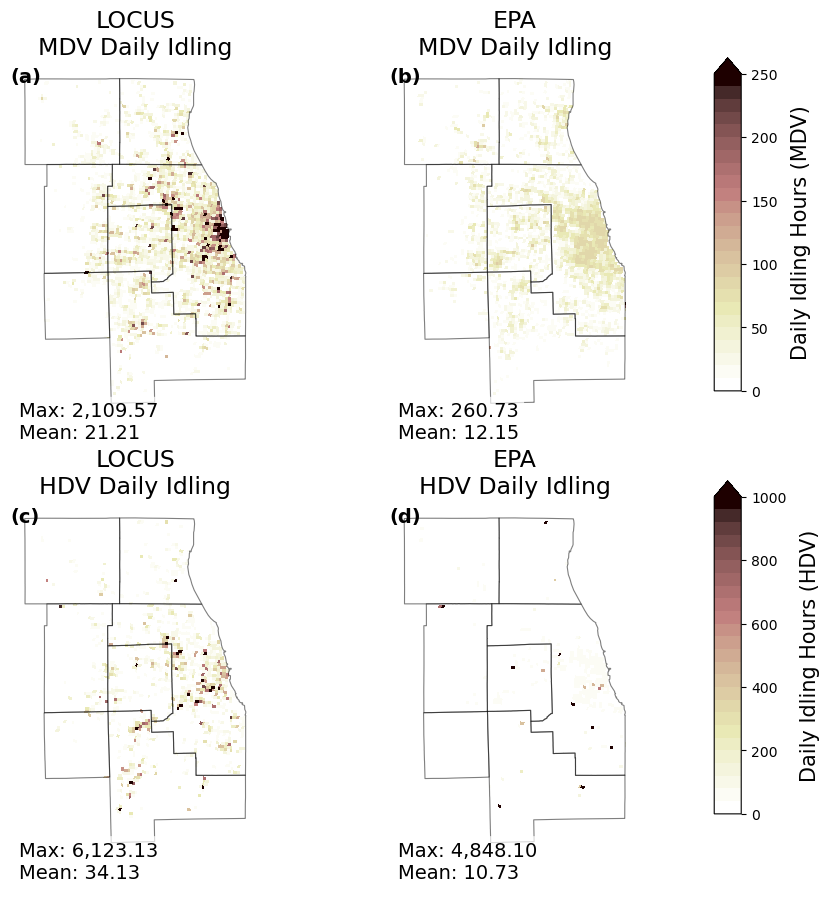

In [33]:
# ============================================================
# FIGURE 3: 2x2
# Top = MDV, Bottom = HDV
# Left = LOCUS, Right = EPA
# ============================================================


fig3, ax = plt.subplots(
    2, 2,
    figsize=(9, 9)
)

# ----------------------------
# MDV row (top)
# ----------------------------
plot_map(
    ax=ax[0, 0],
    gdf=base_cmap,
    col="MDT_avg_da",
    cmap=cmap_discrete,
    vmin=0.0,
    vmax=MDV_VMAX,
    boundary_gdf=cmap_cty,
    title="LOCUS\nMDV Daily Idling",
    stats_text=mdv_locus_stats,
)

plot_map(
    ax=ax[0, 1],
    gdf=s306_cmap,
    col="MDV_Frac_daily",
    cmap=cmap_discrete,
    vmin=0.0,
    vmax=MDV_VMAX,
    boundary_gdf=cmap_cty,
    title="EPA\nMDV Daily Idling",
    stats_text=mdv_epa_stats,
)

# ----------------------------
# HDV row (bottom)
# ----------------------------
plot_map(
    ax=ax[1, 0],
    gdf=base_cmap,
    col="HDT_avg_da",
    cmap=cmap_discrete,
    vmin=0.0,
    vmax=HDV_VMAX,
    boundary_gdf=cmap_cty,
    title="LOCUS\nHDV Daily Idling",
    stats_text=hdv_locus_stats,
)

plot_map(
    ax=ax[1, 1],
    gdf=s306_cmap,
    col="EPA_HDV_total_hours_per_day",
    cmap=cmap_discrete,
    vmin=0.0,
    vmax=HDV_VMAX,
    boundary_gdf=cmap_cty,
    title="EPA\nHDV Daily Idling",
    stats_text=hdv_epa_stats,
)


# ============================================================
# PANEL LABELS
# ============================================================

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for axis, label in zip(ax.flat, panel_labels):
    axis.text(
        -0.015, 0.985,
        label,
        transform=axis.transAxes,
        ha="left",
        va="top",
        fontsize=14,
        fontweight="bold",
        zorder=20,
    )


# ============================================================
# LAYOUT
# ============================================================

fig3.subplots_adjust(
    left=0.035,
    right=0.87,
    bottom=0.055,
    top=0.94,

    # Keep columns close together
    wspace=0.02,

    # IMPORTANT: enough room for top-row stats + bottom-row titles
    hspace=0.23,
)


# ============================================================
# MDV COLORBAR
# ============================================================

cax_mdv = fig3.add_axes([
    0.885,
    0.575,
    0.03,
    0.37
])

sm_mdv = plt.cm.ScalarMappable(
    cmap=cmap_discrete,
    norm=plt.Normalize(0.0, MDV_VMAX)
)
sm_mdv.set_array([])

cbar_mdv = fig3.colorbar(
    sm_mdv,
    cax=cax_mdv,
    extend="max",
)

cbar_mdv.set_label(
    "Daily Idling Hours (MDV)",
    rotation=90,
    labelpad=10,fontsize=15,
)


# ============================================================
# HDV COLORBAR
# ============================================================

cax_hdv = fig3.add_axes([
    0.885,
    0.105,
    0.03,
    0.37
])

sm_hdv = plt.cm.ScalarMappable(
    cmap=cmap_discrete,
    norm=plt.Normalize(0.0, HDV_VMAX)
)
sm_hdv.set_array([])

cbar_hdv = fig3.colorbar(
    sm_hdv,
    cax=cax_hdv,
    extend="max",
)

cbar_hdv.set_label(
    "Daily Idling Hours (HDV)",
    rotation=90,
    labelpad=10,fontsize=15,
)

# ============================================================
# SAVE
# ============================================================

fig3.savefig(
    "MDV_HDV_LOCUS_EPA_GriddedIdling.pdf",
    bbox_inches="tight",
    pad_inches=0.03,
)

fig3.savefig(
    "MDV_HDV_LOCUS_EPA_GriddedIdling.png",
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.03,
)

plt.show()

In [28]:
# # ============================================================
# # FIGURE 1: MDV side-by-side (LOCUS vs EPA)
# # ============================================================
# fig1, ax = plt.subplots(1, 2, figsize=(10, 8))

# mdv_locus_vals = base_cmap["MDT_avg_da"].to_numpy(dtype=float)
# mdv_locus_stats = (
#     f"Max: {np.nanmax(mdv_locus_vals):,.2f}\n"
#     f"Mean: {np.nanmean(mdv_locus_vals):,.2f}\n"
#     #f"Sum: {loc_mdv_total_aw:,.0f}"
# )
# plot_map(
#     ax=ax[0],
#     gdf=base_cmap,
#     col="MDT_avg_da",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=MDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="LOCUS\nMDV Daily Idling",
#     stats_text=mdv_locus_stats,
# )

# mdv_epa_vals = s306_cmap["MDV_Frac_daily"].to_numpy(dtype=float)
# mdv_epa_stats = (
#     f"Max: {np.nanmax(mdv_epa_vals):,.2f}\n"
#     f"Mean: {np.nanmean(mdv_epa_vals):,.2f}\n"
#    # f"Sum: {np.nansum(mdv_epa_vals):,.0f}"
# )
# plot_map(
#     ax=ax[1],
#     gdf=s306_cmap,
#     col="MDV_Frac_daily",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=MDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="EPA\nMDV Daily Idling",
#     stats_text=mdv_epa_stats,
# )

# # --- colorbar: right of the second axis, with extend toward max ---
# fig1.subplots_adjust(right=0.88)   # leave room for cbar

# # Create dedicated colorbar axis
# cax = fig1.add_axes([0.90, 0.15, 0.025, 0.7])
# #                [left, bottom, width, height] (figure coords)

# sm1 = plt.cm.ScalarMappable(
#     cmap=cmap_discrete,
#     norm=plt.Normalize(0.0, MDV_VMAX)
# )
# sm1.set_array([])

# cbar1 = fig1.colorbar(
#     sm1,
#     cax=cax,
#     extend="max",      # arrow beyond vmax
# )

# cbar1.set_label("Daily Idling Hours", rotation=90)

# plt.show()

In [27]:
# # ============================================================
# # FIGURE 2: HDV side-by-side (LOCUS vs EPA)
# # ============================================================
# fig2, ax = plt.subplots(1, 2, figsize=(10, 8))

# hdv_locus_vals = base_cmap["HDT_avg_da"].to_numpy(dtype=float)
# hdv_locus_stats = (
#     f"Max: {np.nanmax(hdv_locus_vals):,.2f}\n"
#     f"Mean: {np.nanmean(hdv_locus_vals):,.2f}\n"
#    # f"Sum: {loc_hdv_total_aw:,.0f}"
# )
# plot_map(
#     ax=ax[0],
#     gdf=base_cmap,
#     col="HDT_avg_da",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=HDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="LOCUS\nHDV Daily Idling",
#     stats_text=hdv_locus_stats,
# )

# hdv_epa_vals = s306_cmap["EPA_HDV_total_hours_per_day"].to_numpy(dtype=float)
# hdv_epa_stats = (
#     f"Max: {np.nanmax(hdv_epa_vals):,.2f}\n"
#     f"Mean: {np.nanmean(hdv_epa_vals):,.2f}\n"
#   #  f"Sum: {np.nansum(hdv_epa_vals):,.0f}"
# )
# plot_map(
#     ax=ax[1],
#     gdf=s306_cmap,
#     col="EPA_HDV_total_hours_per_day",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=HDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="EPA\nHDV Daily Idling ",
#     stats_text=hdv_epa_stats,
# )

# # ------------------------------------------------------------
# # Create space on right for colorbar BEFORE adding it
# # ------------------------------------------------------------
# fig2.subplots_adjust(right=0.88)   # leave room for cbar

# # Dedicated colorbar axis (figure coords)
# cax2 = fig2.add_axes([0.90, 0.15, 0.025, 0.7])  # [left, bottom, width, height]

# sm2 = plt.cm.ScalarMappable(
#     cmap=cmap_discrete,
#     norm=plt.Normalize(0.0, HDV_VMAX)
# )
# sm2.set_array([])

# cbar2 = fig2.colorbar(
#     sm2,
#     cax=cax2,
#     extend="max",
# )
# cbar2.set_label("Daily Idling Hours", rotation=90)

# plt.show()

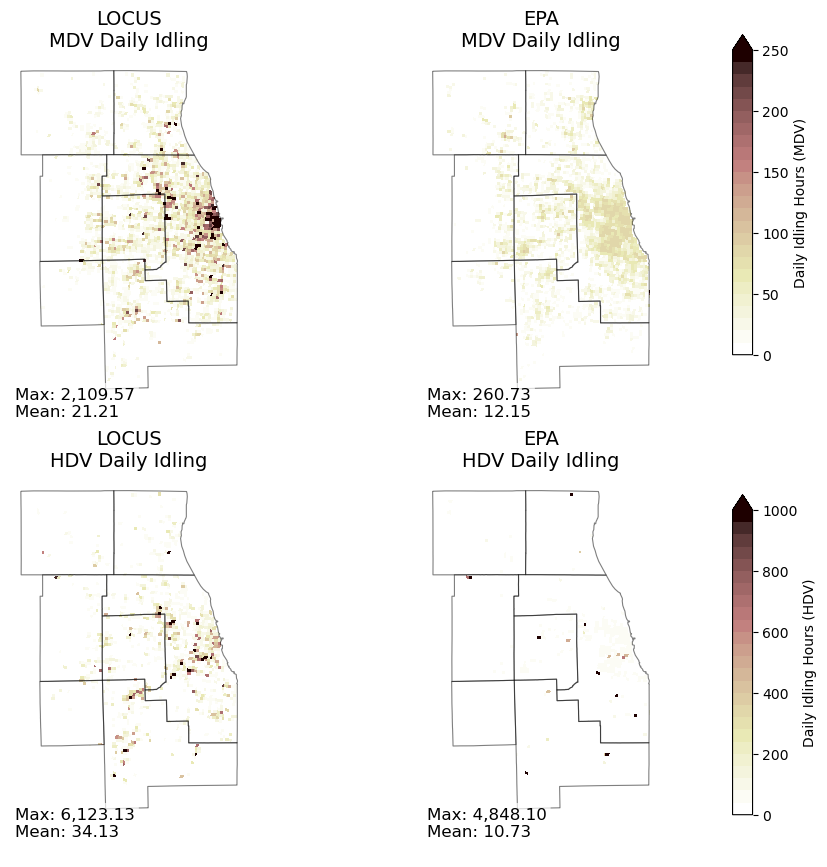

In [12]:
# # ============================================================
# # FIGURE 3: 2x2 (Top=MDV, Bottom=HDV; Left=LOCUS, Right=EPA)
# # ============================================================
# fig3, ax = plt.subplots(2, 2, figsize=(10, 10))

# # ----------------------------
# # MDV row (top)
# # ----------------------------
# plot_map(
#     ax=ax[0, 0],
#     gdf=base_cmap,
#     col="MDT_avg_da",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=MDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="LOCUS\nMDV Daily Idling",
#     stats_text=mdv_locus_stats,
# )
# plot_map(
#     ax=ax[0, 1],
#     gdf=s306_cmap,
#     col="MDV_Frac_daily",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=MDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="EPA\nMDV Daily Idling",
#     stats_text=mdv_epa_stats,
# )

# # ----------------------------
# # HDV row (bottom)
# # ----------------------------
# plot_map(
#     ax=ax[1, 0],
#     gdf=base_cmap,
#     col="HDT_avg_da",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=HDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="LOCUS\nHDV Daily Idling",
#     stats_text=hdv_locus_stats,
# )
# plot_map(
#     ax=ax[1, 1],
#     gdf=s306_cmap,
#     col="EPA_HDV_total_hours_per_day",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=HDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="EPA\nHDV Daily Idling",
#     stats_text=hdv_epa_stats,
# )

# # ------------------------------------------------------------
# # Reserve space on the right for TWO row colorbars
# # ------------------------------------------------------------
# fig3.subplots_adjust(right=0.88)

# # ------------------------------------------------------------
# # Shared colorbar for MDV row (top)
# # ------------------------------------------------------------
# cax_mdv = fig3.add_axes([0.90, 0.58, 0.02, 0.32])  # [left, bottom, width, height]

# sm_mdv = plt.cm.ScalarMappable(
#     cmap=cmap_discrete,
#     norm=plt.Normalize(0.0, MDV_VMAX)
# )
# sm_mdv.set_array([])

# cbar_mdv = fig3.colorbar(
#     sm_mdv,
#     cax=cax_mdv,
#     extend="max",
# )
# cbar_mdv.set_label("Daily Idling Hours (MDV)", rotation=90)

# # ------------------------------------------------------------
# # Shared colorbar for HDV row (bottom)
# # ------------------------------------------------------------
# cax_hdv = fig3.add_axes([0.90, 0.12, 0.02, 0.32])  # [left, bottom, width, height]

# sm_hdv = plt.cm.ScalarMappable(
#     cmap=cmap_discrete,
#     norm=plt.Normalize(0.0, HDV_VMAX)
# )
# sm_hdv.set_array([])

# cbar_hdv = fig3.colorbar(
#     sm_hdv,
#     cax=cax_hdv,
#     extend="max",
# )
# cbar_hdv.set_label("Daily Idling Hours (HDV)", rotation=90)

# # No tight_layout here (it can fight add_axes colorbars)
# plt.savefig("MDV_HDV_LOCUS_EPA_GriddedIdling.pdf")
# plt.show()

In [25]:
# # ============================================================
# # FIGURE 3: 2x2 (Top=MDV, Bottom=HDV; Left=LOCUS, Right=EPA)
# # ============================================================
# fig3, ax = plt.subplots(2, 2, figsize=(10, 10))

# # ----------------------------
# # MDV row (top)
# # ----------------------------
# plot_map(
#     ax=ax[0, 0],
#     gdf=base_cmap,
#     col="MDT_avg_da",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=MDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="LOCUS\nMDV Daily Idling",
#     stats_text=mdv_locus_stats,
# )
# plot_map(
#     ax=ax[0, 1],
#     gdf=s306_cmap,
#     col="MDV_Frac_daily",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=MDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="EPA\nMDV Daily Idling",
#     stats_text=mdv_epa_stats,
# )

# # ----------------------------
# # HDV row (bottom)
# # ----------------------------
# plot_map(
#     ax=ax[1, 0],
#     gdf=base_cmap,
#     col="HDT_avg_da",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=HDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="LOCUS\nHDV Daily Idling",
#     stats_text=hdv_locus_stats,
# )
# plot_map(
#     ax=ax[1, 1],
#     gdf=s306_cmap,
#     col="EPA_HDV_total_hours_per_day",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=HDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="EPA\nHDV Daily Idling",
#     stats_text=hdv_epa_stats,
# )

# # ------------------------------------------------------------
# # Reserve space on the right for TWO row colorbars
# # ------------------------------------------------------------
# fig3.subplots_adjust(right=0.88)

# # ------------------------------------------------------------
# # Shared colorbar for MDV row (top)
# # ------------------------------------------------------------
# cax_mdv = fig3.add_axes([0.90, 0.58, 0.02, 0.32])  # [left, bottom, width, height]

# sm_mdv = plt.cm.ScalarMappable(
#     cmap=cmap_discrete,
#     norm=plt.Normalize(0.0, MDV_VMAX)
# )
# sm_mdv.set_array([])

# cbar_mdv = fig3.colorbar(
#     sm_mdv,
#     cax=cax_mdv,
#     extend="max",
# )
# cbar_mdv.set_label("Daily Idling Hours (MDV)", rotation=90)

# # ------------------------------------------------------------
# # Shared colorbar for HDV row (bottom)
# # ------------------------------------------------------------
# cax_hdv = fig3.add_axes([0.90, 0.12, 0.02, 0.32])  # [left, bottom, width, height]

# sm_hdv = plt.cm.ScalarMappable(
#     cmap=cmap_discrete,
#     norm=plt.Normalize(0.0, HDV_VMAX)
# )
# sm_hdv.set_array([])

# cbar_hdv = fig3.colorbar(
#     sm_hdv,
#     cax=cax_hdv,
#     extend="max",
# )
# cbar_hdv.set_label("Daily Idling Hours (HDV)", rotation=90)

# # No tight_layout here (it can fight add_axes colorbars)
# if SAVE_FIGS:
#     fig3.savefig(FIG3_OUT, dpi=300, bbox_inches="tight")
# plt.show()

In [26]:
# # ============================================================
# # FIGURE 3: 2x2 (Top=MDV, Bottom=HDV; Left=LOCUS, Right=EPA)
# # with panel labels a) b) c) d)
# # ============================================================

# def add_panel_label(ax, label, x=-.05, y=1, fontsize=14):
#     ax.text(
#         x, y, label,
#         transform=ax.transAxes,
#         ha="left", va="top",
#         fontsize=fontsize,
#         fontweight="bold",
#         bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", boxstyle="round,pad=0.2"),
#         zorder=20,
#     )

# fig3, ax = plt.subplots(2, 2, figsize=(10, 10))

# # ----------------------------
# # MDV row (top)
# # ----------------------------
# plot_map(
#     ax=ax[0, 0],
#     gdf=base_cmap,
#     col="MDT_avg_da",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=MDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="LOCUS\nMedium-Duty Vehicle Idling",
#     stats_text=mdv_locus_stats,
# )
# add_panel_label(ax[0, 0], "a)")

# plot_map(
#     ax=ax[0, 1],
#     gdf=s306_cmap,
#     col="MDV_Frac_daily",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=MDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="EPA\nMedium-Duty Vehicle Idling",
#     stats_text=mdv_epa_stats,
# )
# add_panel_label(ax[0, 1], "b)")

# # ----------------------------
# # HDV row (bottom)
# # ----------------------------
# plot_map(
#     ax=ax[1, 0],
#     gdf=base_cmap,
#     col="HDT_avg_da",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=HDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="LOCUS\nHeavy-Duty Vehicle Idling",
#     stats_text=hdv_locus_stats,
# )
# add_panel_label(ax[1, 0], "c)")

# plot_map(
#     ax=ax[1, 1],
#     gdf=s306_cmap,
#     col="EPA_HDV_total_hours_per_day",
#     cmap=cmap_discrete,
#     vmin=0.0,
#     vmax=HDV_VMAX,
#     boundary_gdf=cmap_cty,
#     title="EPA\nHeavy-Duty Vehicle Idling",
#     stats_text=hdv_epa_stats,
# )
# add_panel_label(ax[1, 1], "d)")

# # ------------------------------------------------------------
# # Reserve space on the right for TWO row colorbars
# # ------------------------------------------------------------
# fig3.subplots_adjust(right=0.88)

# # ------------------------------------------------------------
# # Shared colorbar for MDV row (top)
# # ------------------------------------------------------------
# cax_mdv = fig3.add_axes([0.90, 0.58, 0.02, 0.32])

# sm_mdv = plt.cm.ScalarMappable(
#     cmap=cmap_discrete,
#     norm=plt.Normalize(0.0, MDV_VMAX)
# )
# sm_mdv.set_array([])

# cbar_mdv = fig3.colorbar(
#     sm_mdv,
#     cax=cax_mdv,
#     extend="max",
# )
# cbar_mdv.set_label("Daily Idling Hours", rotation=90,fontsize=14)
# # ------------------------------------------------------------
# # Shared colorbar for HDV row (bottom)
# # ------------------------------------------------------------
# cax_hdv = fig3.add_axes([0.90, 0.12, 0.02, 0.32])

# sm_hdv = plt.cm.ScalarMappable(
#     cmap=cmap_discrete,
#     norm=plt.Normalize(0.0, HDV_VMAX)
# )
# sm_hdv.set_array([])

# cbar_hdv = fig3.colorbar(
#     sm_hdv,
#     cax=cax_hdv,
#     extend="max",
# )
# cbar_hdv.set_label("Daily Idling Hours", rotation=90,fontsize=14)

# if SAVE_FIGS:
#     fig3.savefig(FIG3_OUT, dpi=300, bbox_inches="tight")

# plt.show()